<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%209.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 회귀 실습 - 자전거 대여 수요 예측

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pit
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

bike_df = pd.read_csv('train.csv')
print(bike_df.shape)
bike_df.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB




*   판다스에서는 datetime과 같은 형태의 문자열을 년도, 월, 일, 시간, 분, 초로 편리하게 변환하려면 먼저 문자열을 'datetime' 타입으로 변경해야 한다. 판다스는 문자열을 datetime 타입으로 변환하는 apply(pd.to_datetime) 메서드를 제공한다.



In [4]:
## 문자열을 datetime 타입으로 변경한다
bike_df['datetime'] = bike_df['datetime'].apply(pd.to_datetime)

## datetime 타입에서 년, 월, 일, 시간을 추출한다
bike_df['year'] = bike_df['datetime'].apply(lambda x : x.year)
bike_df['month'] = bike_df['datetime'].apply(lambda x : x.month)
bike_df['day'] = bike_df['datetime'].apply(lambda x : x.day)
bike_df['hour'] = bike_df['datetime'].apply(lambda x: x.hour)
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2


In [5]:
drop_columns = ['datetime','casual','registered']
bike_df.drop(drop_columns, axis=1, inplace=True)

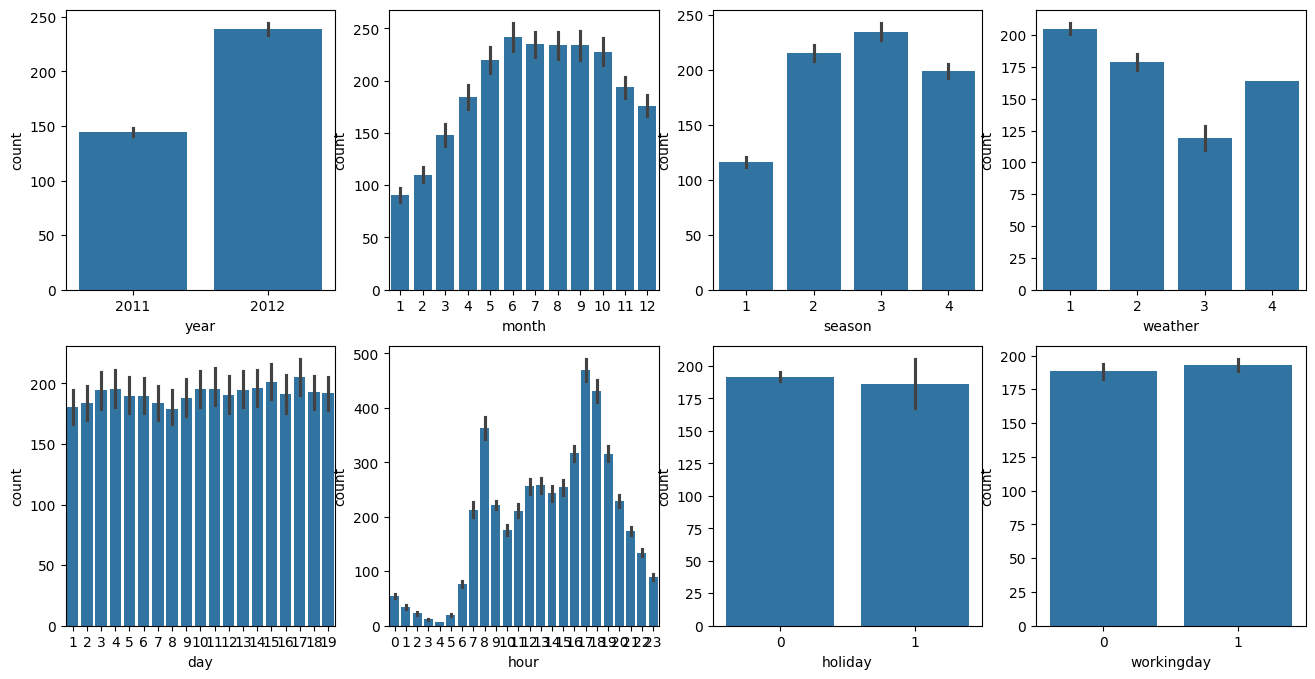

In [6]:
fig, axs= pit.subplots(figsize=(16,8), ncols=4, nrows=2)
cat_features= ['year', 'month', 'season','weather','day','hour','holiday','workingday']
## cat_features에 있는 모든 칼럼별로 개별 칼럼값에 따른 count의 합을 barplot으로 시각화한다
for i, feature in enumerate(cat_features):
    row= int(i/4)
    col= i%4
    ## 시본의 barplot을 이용해 컬럼값에 따른 count의 합을 표현한다
    sns.barplot(x=feature, y='count', data=bike_df, ax=axs[row][col])

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
## RMSLE를 수행하는 성능 평가 함수

## log값 변환 시 NaN 등의 이슈로 log()가 아닌 log1p()를 이용해 RMSLE를 계산한다
def rmsle(y, pred):
  log_y = np.log1p(y)
  log_pred = np.log1p(pred)
  squared_error = (log_y - log_pred) ** 2
  rmsle = np.sqrt(np.mean(squared_error))
  return rmsle

## 사이킷런의 mean_square_error()를 이용해 RMSE를 계산한다
def rmse(y, pred):
  return np.sqrt(mean_squared_error(y, pred))

## MAE, RMSE, RMSLE를 모두 계산한다
def evaluate_regr(y, pred):
  rmsle_val = rmsle(y, pred)
  rmse_val = rmse(y, pred)
  ## MAE는 사이킷런의 mean_absolute_error()로 계산한다
  mae_val = mean_absolute_error(y, pred)
  print('RMSLE: {0:3f}, RMSE: {1:3f}, MAE: {2:3f}'.format(rmsle_val, rmse_val, mae_val))

In [8]:
## 다음과 같은 RMSLE 구현은 오버플로우나 언더플로우 오류가 발생하기 쉽다
## def rmsle(y, pred):
##  msle = mean_squared_log_error(y, pred)
##  rmsle= np.sqrt(msle)
##  return rmsle

In [9]:
## 사이킷런의 LinearRegression 객체를 이용해 회귀 예측을 진행한다
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso

y_target = bike_df['count']
X_features = bike_df.drop(['count'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)

evaluate_regr(y_test, pred)

RMSLE: 1.164664, RMSE: 140.899589, MAE: 105.924448


/tmp/ipykernel_4866/490418026.py:7: RuntimeWarning: invalid value encountered in log1p
  log_pred = np.log1p(pred)


In [10]:
## 실제 값과 예측값이 어느 정도 차이가 나는지 DataFrame의 칼럼으로 만들어 오류 값이 가장 큰 순으로 5개를 확인한다
def get_top_error_data(y_test, pred, n_tops=5):
  ## DataFrame의 칼럼으로 실제 대여 횟수(count)와 예측값을 서로 비교할 수 있도록 생성한다
  result_df = pd.DataFrame(y_test.values, columns=['real_count'])
  result_df['predicted_count']= np.round(pred)
  result_df['diff'] = np.abs(result_df['real_count'] - result_df['predicted_count'])

  ## 예측값과 실제 값이 가장 큰 데이터 순으로 출력한다
  print(result_df.sort_values('diff', ascending=False)[:n_tops])

get_top_error_data(y_test, pred, n_tops=5)

      real_count  predicted_count   diff
1618         890            322.0  568.0
966          884            327.0  557.0
3151         798            241.0  557.0
412          745            194.0  551.0
2817         856            310.0  546.0


<Axes: >

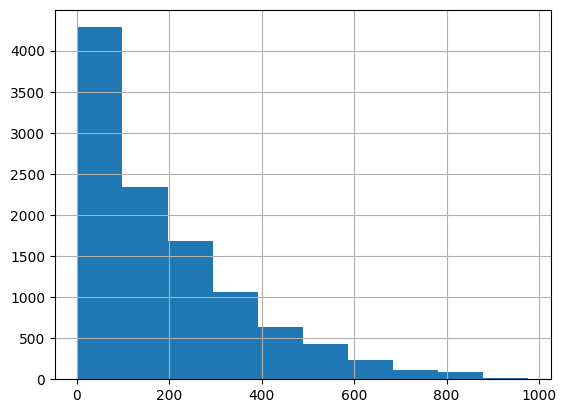

In [11]:
## 자전거 대여 모델의 Target 값인 count 칼럼이 정규 분포를 이루는지 확인한다
y_target.hist()

<Axes: >

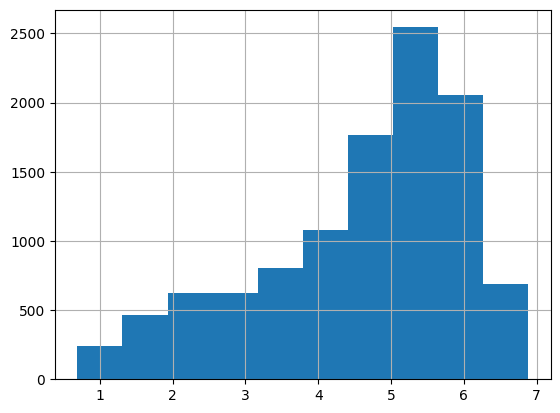

In [12]:
## 왜곡된 값을 로그 변환을 이용해 정규분포 형태로 바꾼다
y_log_transform = np.log1p(y_target)
y_log_transform.hist()

In [13]:
## 정규분포 형태는 아니지만 왜곡 정도가 향상된 Target 값을 가지고 다시 학습 후 평가를 수행한다
## 타깃 칼럼인 count 값을 loglp로 로그 변환한다
y_target_log = np.log1p(y_target)

## 로그 변환된 y_target_log를 반영해 학습/테스트 데이터 세트를 분할한다
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target_log, test_size=0.3, random_state=0)
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
pred = lr_reg.predict(X_test)

## 테스트 데이터 세트의 Target 값은 로그 변환됐으므로 다시 expm1을 이용해 원래 스케일로 변환한다
y_test_exp = np.expm1(y_test)

## 예측값 역시 로그 변환된 타깃 기반으로 학습돼 예측됐으므로 다시 expm1로 스케일 변환을 진행한다
pred_exp = np.expm1(pred)

evaluate_regr(y_test_exp, pred_exp)

RMSLE: 1.016827, RMSE: 162.594268, MAE: 109.286159


<Axes: ylabel='None'>

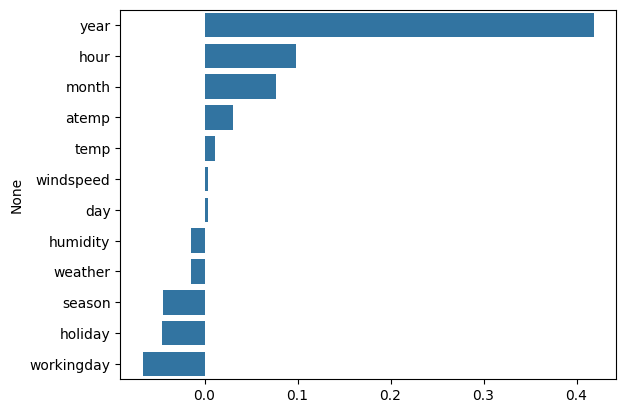

In [14]:
## 각 피처의 회귀 계숫값을 시각화한다
coef = pd.Series(lr_reg.coef_, index = X_features.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

In [15]:
## 판다스의 get_dummies()를 이용해 year, month, day, hour, holiday, workingday, season, weather 칼럼을 모두 원-핫 인코딩한다
X_features_ohe = pd.get_dummies(X_features, columns=['year','month','day','hour','holiday','workingday','season','weather'])

In [16]:
## 원핫 인코딩이 적용된 피처 데이터 세트 기반으로 학습/예측 데이터를 분할한다
X_train, X_test, y_train, y_test = train_test_split(X_features_ohe, y_target_log, test_size=0.3, random_state=0)

## 모델과 학습/테스트 데이터 세트를 입력하면 성능 평가 수치를 반환하는 함수
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False):
  model.fit(X_train, y_train)
  pred = model.predict(X_test)
  if is_expm1 :
    y_test = np.expm1(y_test)
    pred = np.expm1(pred)
  print('###', model.__class__.__name__, '###')
  evaluate_regr(y_test, pred)

## 모델별로 평가를 수행한다
lr_reg = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)

for model in [lr_reg, ridge_reg, lasso_reg]:
  get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=True)

### LinearRegression ###
RMSLE: 0.589634, RMSE: 97.687643, MAE: 63.382029
### Ridge ###
RMSLE: 0.590137, RMSE: 98.528591, MAE: 63.893353
### Lasso ###
RMSLE: 0.634752, RMSE: 113.218810, MAE: 72.802707


<Axes: ylabel='None'>

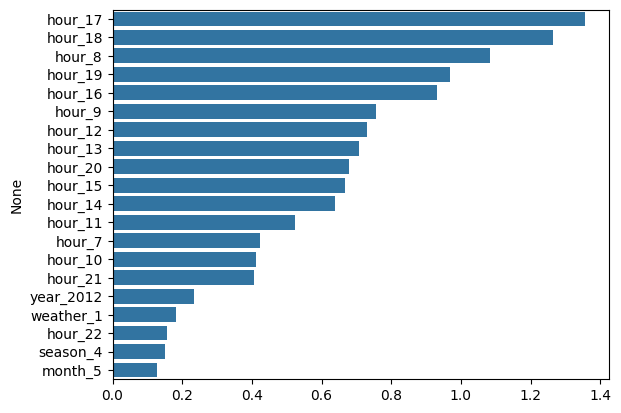

In [17]:
## 회귀 계수 상위 20개 피처를 추출한다
coef = pd.Series(lr_reg.coef_, index=X_features_ohe.columns)
coef_sort = coef.sort_values(ascending=False)[:20]
sns.barplot(x=coef_sort.values, y=coef_sort.index)

In [18]:
## 회귀 트리를 이용해 회귀 예측을 수행한다
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 랜덤 포레스트, GBM, XGBoost, LightGBM 모델별로 평가를 수행한다
rf_reg = RandomForestRegressor(n_estimators=500)
gbm_reg = GradientBoostingRegressor(n_estimators=500)
xgb_reg = XGBRegressor(n_estimators=500)
lgbm_reg = LGBMRegressor(n_estimators=500)

for model in [rf_reg, gbm_reg, xgb_reg, lgbm_reg]:
  ## XGBoost의 경우 DataFrame이 입력될 경우 버전에 따라 오류가 발생할 수 있으므로 ndarray로 변환한다
  get_model_predict(model, X_train.values, X_test.values, y_train.values, y_test.values, is_expm1=True)

### RandomForestRegressor ###
RMSLE: 0.353942, RMSE: 50.295096, MAE: 31.074260
### GradientBoostingRegressor ###
RMSLE: 0.329919, RMSE: 53.349976, MAE: 32.745992
### XGBRegressor ###
RMSLE: 0.338795, RMSE: 51.475410, MAE: 31.356583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000763 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 348
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 72
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE: 0.318846, RMSE: 47.214647, MAE: 29.028770


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 회귀 실습 - 캐글 주택 가격: 고급 회귀 기법

In [20]:
## 데이터 사전처리를 진행한다
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

house_df_org = pd.read_csv('/content/train_houseprices.csv')
house_df = house_df_org.copy()
house_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [21]:
## 데이터 세트의 전체 크기와 칼럼의 타입, 그리고 Null이 있는 칼럼과 그 건수를 내림차순으로 출력한다
print('데이터 세트의 Shape:',house_df.shape)
print('\n 전체 피처의 type \n', house_df.dtypes.value_counts())
isnull_series = house_df.isnull().sum()
print('\n Null 칼럼과 그 건수: \n', isnull_series[isnull_series > 0].sort_values(ascending=False))

데이터 세트의 Shape: (1460, 81)

 전체 피처의 type 
 object     43
int64      35
float64     3
Name: count, dtype: int64

 Null 칼럼과 그 건수: 
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


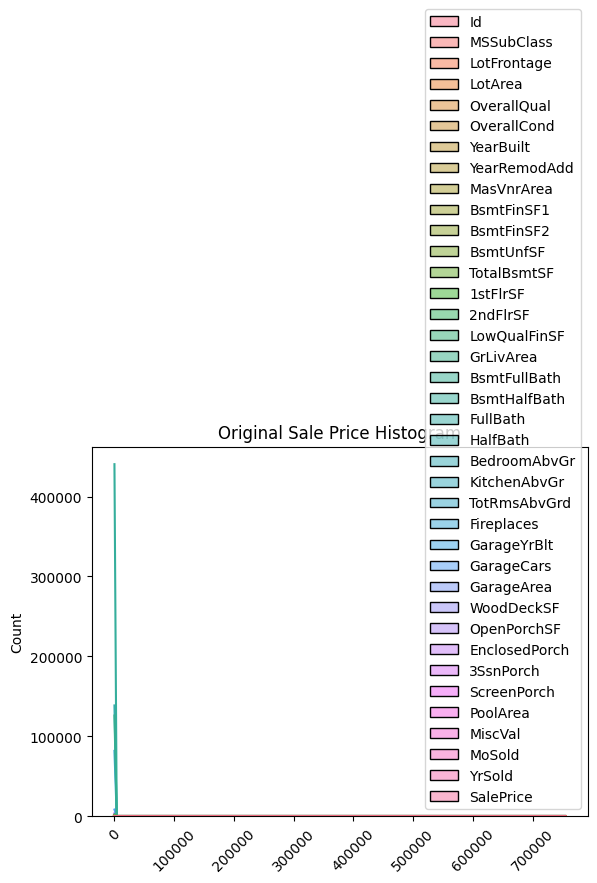

In [23]:
## 회귀 모델을 적용하기 전에 타깃 값의 분포도를 확인한다
plt.title('Original Sale Price Histogram')
plt.xticks(rotation=45)
sns.histplot(house_df, kde=True)
plt.show()

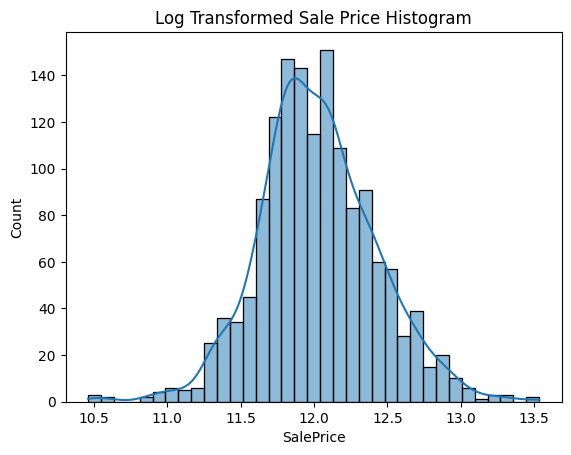

In [25]:
## 로그 변환을 적용한다
plt.title('Log Transformed Sale Price Histogram')
log_saleprice = np.log1p(house_df['SalePrice'])
sns.histplot(log_saleprice, kde=True)
plt.show()

In [26]:
## SalePrice 로그 변환을 수행한다
original_SalePrice = house_df['SalePrice']
house_df['SalePrice'] = np.log1p(house_df['SalePrice'])

## Null이 너무 많은 칼럼과 불필요한 칼럼을 삭제한다
house_df.drop(['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'], axis=1, inplace=True)

## 드롭하지 않은 숫자형 Null 칼럼은 평균값으로 대체한다
numerical_cols = house_df.select_dtypes(include=np.number).columns
house_df[numerical_cols] = house_df[numerical_cols].fillna(house_df[numerical_cols].mean())

## Null 값이 있는 피처명과 타입을 추출한다
null_column_count = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('## Null 피처의 Type: \n', house_df.dtypes[null_column_count.index])

## Null 피처의 Type: 
 MasVnrType      object
BsmtQual        object
BsmtCond        object
BsmtExposure    object
BsmtFinType1    object
BsmtFinType2    object
Electrical      object
GarageType      object
GarageFinish    object
GarageQual      object
GarageCond      object
dtype: object


In [27]:
print('get_dummies() 수행 전 데이터 Shape:', house_df.shape)
house_df_ohe = pd.get_dummies(house_df)
print('get_dummies() 수행 후 데이터 Shape:', house_df_ohe.shape)

null_column_count = house_df_ohe.isnull().sum()[house_df_ohe.isnull().sum() > 0]
print('## Null 피처의 Type :\n', house_df_ohe.dtypes[null_column_count.index])

get_dummies() 수행 전 데이터 Shape: (1460, 75)
get_dummies() 수행 후 데이터 Shape: (1460, 270)
## Null 피처의 Type :
 Series([], dtype: object)


In [28]:
## RMSE를 계산하는 함수
def get_rmse(model):
  pred = model.predict(X_test)
  mse = mean_squared_error(y_test, pred)
  rmse = np.sqrt(mse)
  print (model.__class__.__name__, '로그 변환된 RMSE: ', np.round(rmse, 3))
  return rmse

def get_rmses(models):
  rmses = [ ]
  for model in models:
    rmse = get_rmse(model)
    rmses.append(rmse)
  return rmses

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1 , inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

## LinearRegression, Ridge, Lasso 학습, 예측, 평가를 진행한다
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

LinearRegression 로그 변환된 RMSE:  0.132
Ridge 로그 변환된 RMSE:  0.127
Lasso 로그 변환된 RMSE:  0.176


[np.float64(0.13183184688250701),
 np.float64(0.1274058283626616),
 np.float64(0.17628250556471403)]

In [32]:
## 회귀 계수 값의 상위 10개, 하위 10개의 피처명과 그 회귀 계수 값을 가지는 판다스 Series 객체를 반환하는 함수를 만든다
def get_top_bottom_coef(model, rr=10):
  ## coef_ 속성을 기반으로 Series 객체를 생성한다. 이 때 index는 칼럼명이다
  coef = pd.Series(model.coef_, index=X_features.columns)

  ## + 상위 10개 하위 10개의 회귀 계수를 추출해 반환한다
  coef_high = coef.sort_values(ascending=False).head(rr)
  coef_low = coef.sort_values(ascending=False).tail(rr)
  return coef_high, coef_low

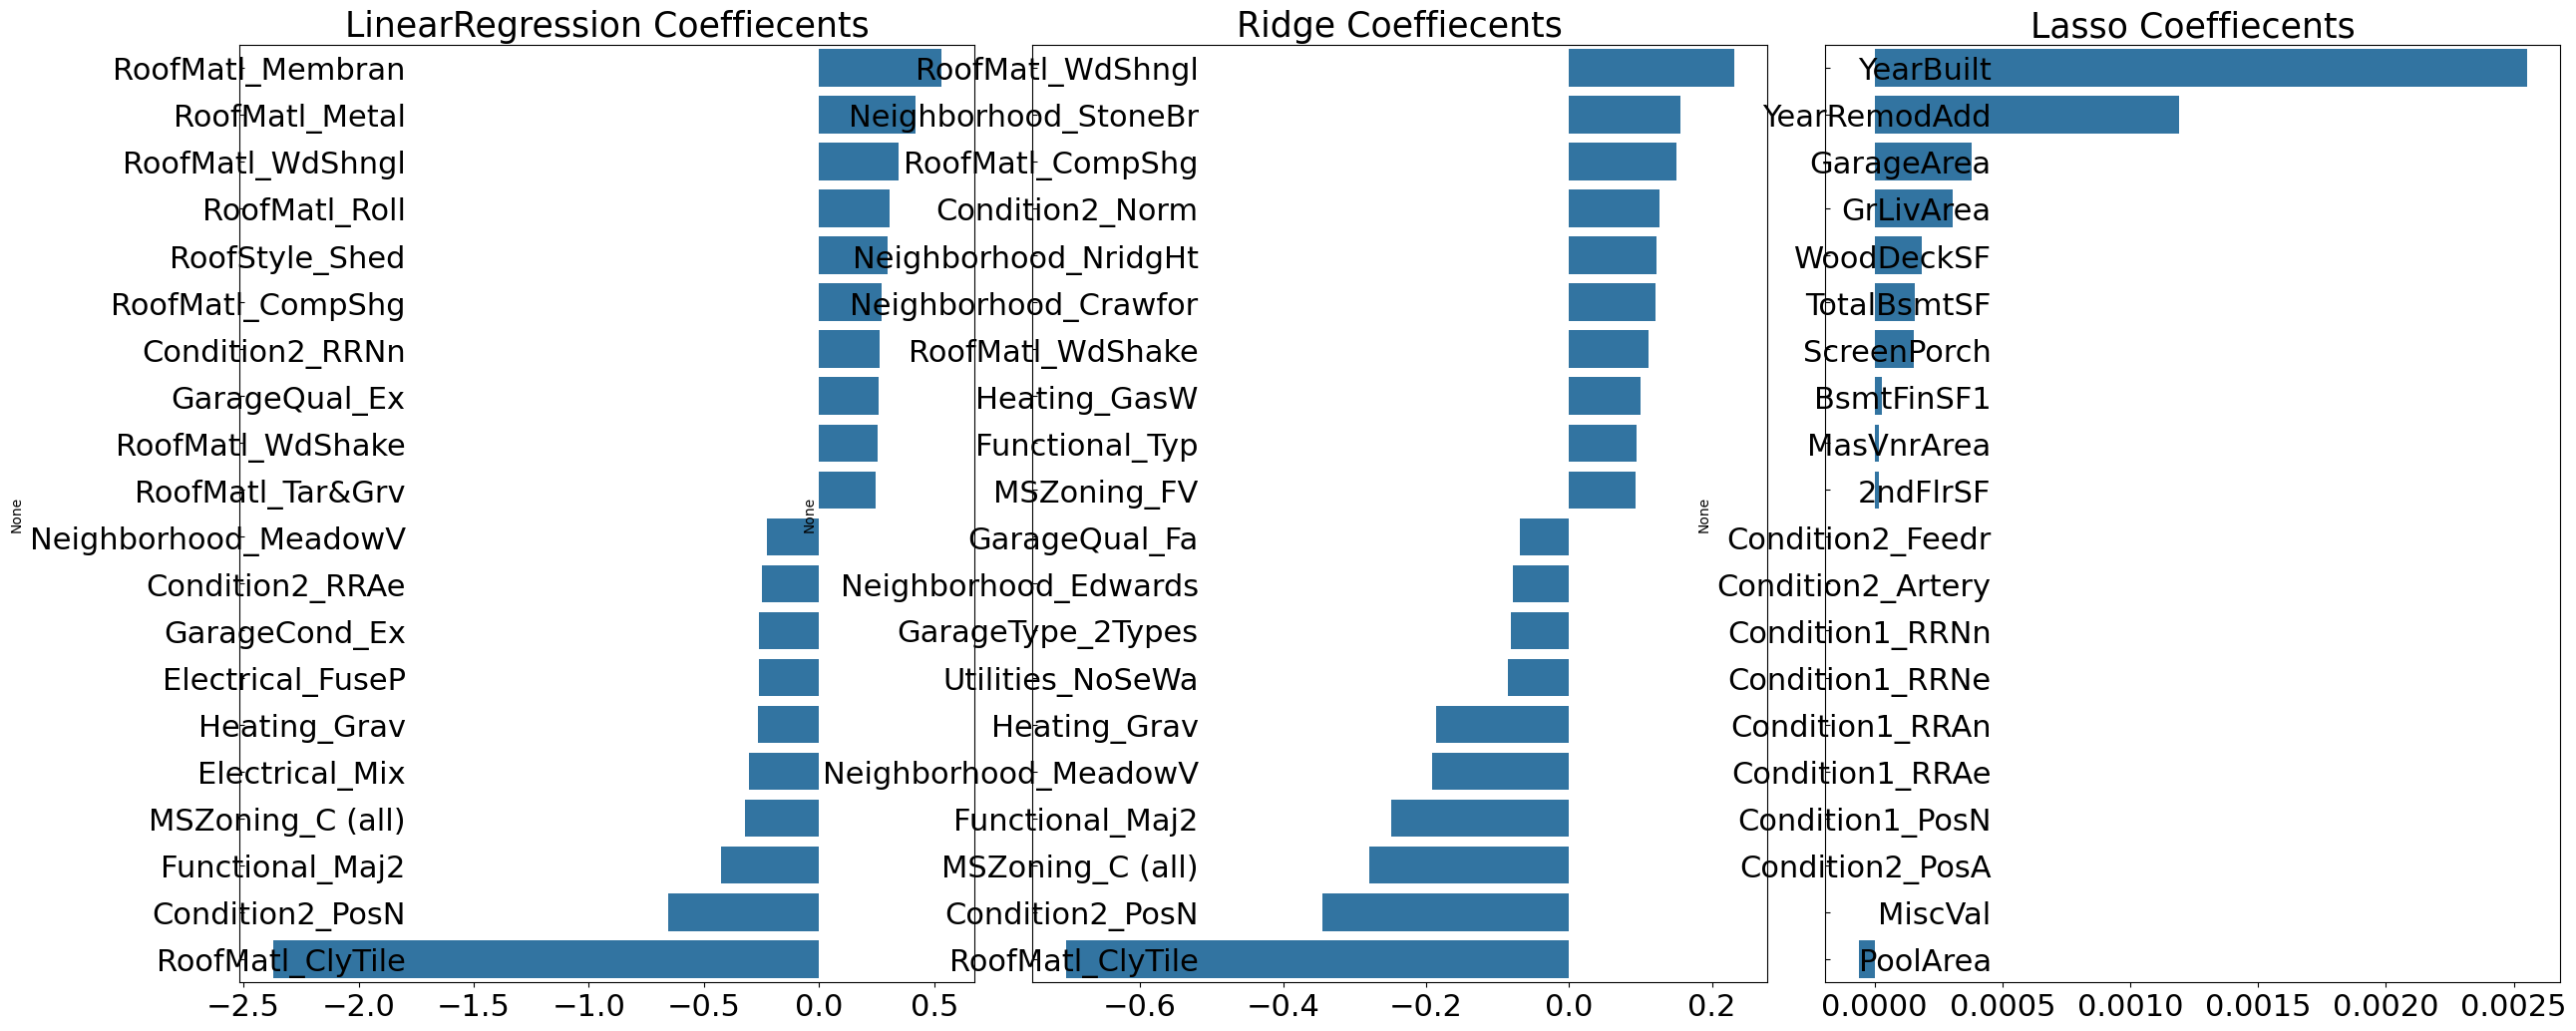

In [33]:
## 생성한 함수를 이용해 모델별 회귀 계수를 시각화한다
def visualize_coefficient(models):
  ## 3개 회귀 모델의 시각화를 위해 3개의 칼럼을 가지는 subplot을 생성한다
  fig, axs = pit.subplots(figsize=(24, 10), nrows=1, ncols=3)
  fig.tight_layout()
  ## 입력 인자로 받은 list 객체인 models에서 차례로 model을 추출해 회귀 계수를 시각화한다
  for i_num, model in enumerate(models):
    ## 상위 10개 하위 10개의 회귀 계수를 구하고 이를 판다스 concat으로 결합한다
    coef_high, coef_low = get_top_bottom_coef(model)
    coef_concat = pd.concat([coef_high, coef_low])
    ## ax subplot에 barchar로 표현한다. 이 때 한 화면에 표현하기 위해 tick label 위치와 font 크기를 조정한다
    axs[i_num].set_title(model.__class__.__name__ + ' Coeffiecents', size=25)
    axs[i_num].tick_params(axis="y", direction="in", pad=-120)
    for label in (axs[i_num].get_xticklabels() + axs[i_num].get_yticklabels()):
      label.set_fontsize(22)
    sns.barplot(x=coef_concat.values, y=coef_concat.index, ax=axs[i_num])

## 앞 예제에서 학습한 lr_reg, ridge_reg, lasso_reg 모델의 회귀 계수를 시각화한다
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)

In [35]:
from sklearn.model_selection import cross_val_score

def get_cv_rmse(models):
  for model in models:
    ## train_test_split()으로 분할하지 않고 전체 데이터로 cross_val_score()을 수행한다
    rmse_list = np.sqrt(-cross_val_score(model, X_features, y_target, scoring="neg_mean_squared_error", cv=5))
    rmse_avg = np.mean(rmse_list)
    print('\n{0} CV RMSE 리스트: {1}'.format(model.__class__.__name__, np.round(rmse_list, 3)))
    print('{0} CV 평균 RMSE: {1}'.format(model.__class__.__name__, np.round(rmse_avg, 3)))

## 앞 예제에서 학습한 ridge_reg, lasso_reg 모델의 CV RMSE값을 출력한
models = [lr_reg, ridge_reg, lasso_reg]
get_cv_rmse(models)


LinearRegression CV RMSE 리스트: [0.135 0.165 0.167 0.111 0.198]
LinearRegression CV 평균 RMSE: 0.155

Ridge CV RMSE 리스트: [0.117 0.154 0.142 0.117 0.189]
Ridge CV 평균 RMSE: 0.144

Lasso CV RMSE 리스트: [0.161 0.204 0.177 0.181 0.265]
Lasso CV 평균 RMSE: 0.198


In [36]:
## 모델별로 최적화 하이퍼 파라미터 작업을 반복적으로 진행하기 위한 함수를 생성한다
## 모델과 하이퍼 파라미터 딕셔너리 객체를 받아 최적화 작업의 결과를 표시하는 함수를 생성한다
from sklearn.model_selection import GridSearchCV

def print_best_params(model, params):
  grid_model = GridSearchCV(model, param_grid=params, scoring='neg_mean_squared_error', cv=5)
  grid_model.fit(X_features, y_target)
  rmse = np.sqrt(-1*grid_model.best_score_)
  print('{0} 5 CV 시 최적 평균 RMSE 값: {1} 최적 alpha: {2}'.format(model.__class__.__name__,np.round(rmse,4), grid_model.best_params_))

ridge_params = { 'alpha' : [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = { 'alpha' : [0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1418 최적 alpha: {'alpha': 12}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.142 최적 alpha: {'alpha': 0.001}


LinearRegression 로그 변환된 RMSE:  0.132
Ridge 로그 변환된 RMSE:  0.124
Lasso 로그 변환된 RMSE:  0.12


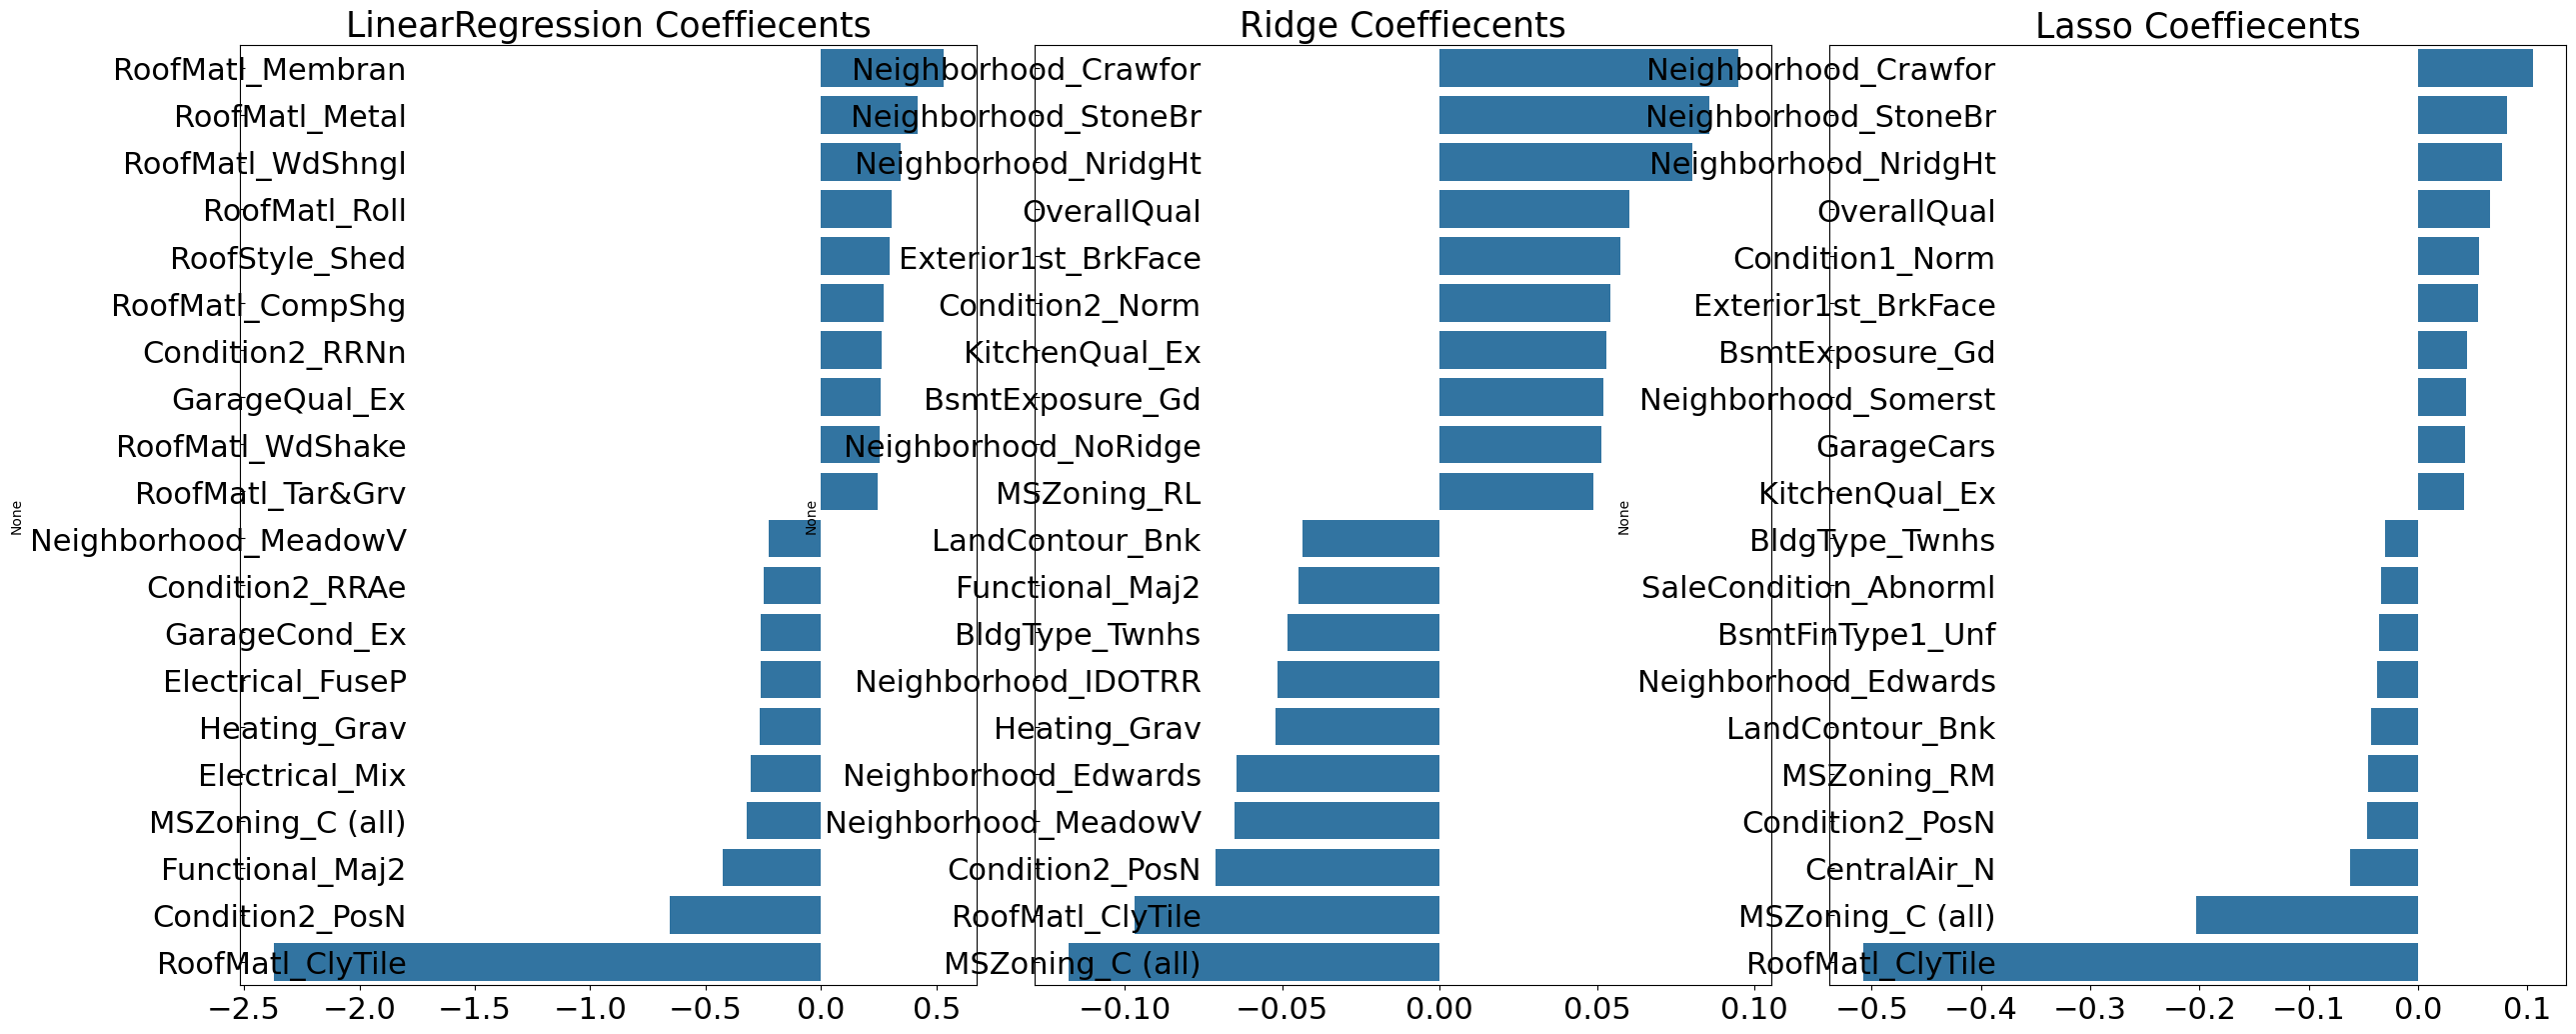

In [37]:
## 앞의 최적화 alpha 값으로 학습 데이터로 학습하며, 테스트 데이터로 예측 및 평가를 수행한다
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge(alpha=12)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

## 모든 모델의 RMSE를 출력한다
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models)

## 모든 모델의 회귀 계수를 시각화한다
models = [lr_reg, ridge_reg, lasso_reg]
visualize_coefficient(models)



*   사이파이 stats 모듈의 skew() 함수를 이용해 칼럼의 데이터 세트의 왜곡된 정도를 쉽게 추출할 수 있다. 일반적으로 skew() 함수의 반환 값이 1 이상인 경우를 왜곡 정도가 높다고 판단하지만 상황에 따라 편차가 존재한다. 이 때 skew()를 적용하는 숫자형 피처에서 원-핫 인코딩된 카테고리 숫자형 피처는 제외해야 한다. 카테고리 피처는 코드성 피처이므로 인코딩 시 왜곡될 가능성이 높기 때문이다.



In [38]:
from scipy.stats import skew

## object가 아닌 숫자형 피처의 칼럼 index 객체를 추출한다
features_index = house_df.dtypes[house_df.dtypes != "object"].index
## house_df에 칼럼 index를 []로 입력하면 해당하는 칼럼 데이터 세트를 반환한다. apply lambda로 skew()를 호출한다
skew_features = house_df[features_index].apply(lambda x:skew(x))
## skew 정도가 1 이상인 칼럼만을 추출한다
skew_features_top = skew_features[skew_features > 1]
print(skew_features_top.sort_values(ascending=False))

MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.673661
LotFrontage       2.382499
OpenPorchSF       2.361912
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
dtype: float64


In [39]:
## 추출된 왜곡 정도가 높은 피처를 로그 변환한다
house_df[skew_features_top.index] = np.log1p(house_df[skew_features_top.index])

In [40]:
## house_df의 피처를 일부 로그 변환했으므로 다시 원-핫 인코딩을 적용한 house_df_ohe를 만든다
house_df_ohe = pd.get_dummies(house_df)
## 이에 기반한 피처/타깃 데이터 세트, 학습/테스트 데이터 세트를 모두 다시 만든다
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

## 피처를 로그 변환한 후 다시 최적 하이퍼 파라미터와 RMSE를 출력한다
ridge_params = {'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5, 10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1275 최적 alpha: {'alpha': 10}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.1252 최적 alpha: {'alpha': 0.001}


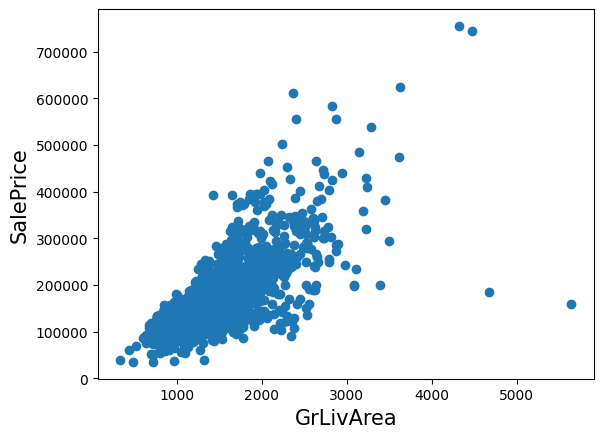

In [41]:
pit.scatter(x=house_df_org['GrLivArea'], y=house_df_org['SalePrice'])
pit.ylabel('SalePrice', fontsize=15)
pit.xlabel('GrLivArea', fontsize=15)
plt.show()

GrLivArea가 4000을 넘은 두 데 이터는 일반적인 GrLivArea와 SalePrice 관계에서 너무 어긋나있다.

In [42]:
## GrLivArea와 SalePrice 모두 로그 변환됐으므로 이를 반영한 조건을 생성한다
cond1 = house_df_ohe['GrLivArea'] > np.log1p(4000)
cond2 = house_df_ohe['SalePrice'] < np.log1p(500000)
outlier_index = house_df_ohe[cond1 & cond2].index

print('이상치 레코드 index:', outlier_index.values)
print('이상치 삭제 전 house_df_ohe shape:', house_df_ohe.shape)

## DataFrame의 인덱스를 이용해 이상치 레코드를 삭제한다
house_df_ohe.drop(outlier_index, axis=0, inplace=True)
print('이상치 삭제 후 house_df_ohe shape:', house_df_ohe.shape)

이상치 레코드 index: [ 523 1298]
이상치 삭제 전 house_df_ohe shape: (1460, 270)
이상치 삭제 후 house_df_ohe shape: (1458, 270)


In [44]:
## 업데이트된 house_df_ohe를 기반으로 피처/타깃 데이터 세트를 다시 생성한다
y_target = house_df_ohe['SalePrice']
X_features = house_df_ohe.drop('SalePrice', axis=1, inplace=False)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=156)

## print_best_params() 함수를 이용해 릿지와 라쏘 모델의 최적화를 수행하고 결과를 출력한다
ridge_params = {'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1, 5,10]}
print_best_params(ridge_reg, ridge_params)
print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.1125 최적 alpha: {'alpha': 8}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.1122 최적 alpha: {'alpha': 0.001}




*   이상치를 찾는 것은 쉽지 않지만 회귀에 중요한 영향을 미치는 피처를 위주로 이상치 데이터를 찾으려는 노력은 중요하다. 보통 머신러닝 프로세스 중 데이터의 가공은 알고리즘을 적용하기 이전에 수행한다. 하지만 이것이 머신러닝 알고리즘을 적용하기 이전에 완벽하게 데이터의 선처리 작업을 수행하라는 것은 아니다. 일단 대략의 데이터 가공과 모델 최적화를 수행한 뒤, 다시 이에 기반한 여러 기법의 데이터 가공과 하이퍼 파라미터 기반의 모델 최적화를 반복해 수행하는 것이 바람직한 머신러닝 모델 생성 과정이다.



### 회귀 트리 모델 학습/예측/평가

In [45]:
from xgboost import XGBRegressor
xgb_params = {'n_estimators':[1000]}
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
print_best_params(xgb_reg, xgb_params)

XGBRegressor 5 CV 시 최적 평균 RMSE 값: 0.1206 최적 alpha: {'n_estimators': 1000}


In [47]:
from lightgbm import LGBMRegressor
lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
print_best_params(lgbm_reg, lgbm_params)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3155
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 171
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3167
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 168
[LightGBM] [Info] Start training from score 12.023516
[LightGBM] [Warning] Found

### 회귀 모델의 예측 결과 혼합을 통한 최종 예측


*   예측 결과 혼합이란 가령 A 모델과 B 모델의 두 모델의 예측값이 있다면 A 모델 예측 값의 40%, B 모델 예측값의 60%를 더해서 최종 회귀 값으로 예측하는 것이다. (* 이 때 두 개 중 성능이 조금 더 좋은 쪽에 가중치를 약간 더 둘 수 있다.) A 회귀 모델의 예측값이 [100, 80, 60]이고 B 회귀 모델의 예측값이 [120, 80, 50]이라면 최종 회귀 예측값은 [112, 80, 54]가 된다.



In [48]:
## 최종 혼합 모델, 개별 모델의 RMSE 값을 출력하는 함수를 생성한다
def get_rmse_pred(preds):
  for key in preds.keys():
    pred_value = preds[key]
    mse = mean_squared_error(y_test, pred_value)
    rmse = np.sqrt(mse)
    print('{0} 모델의 RMSE: {1}'.format(key, rmse))

## 개별 모델의 학습을 진행한다
ridge_reg = Ridge(alpha=8)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

## 개별 모델의 예측을 진행한다
ridge_pred = ridge_reg.predict(X_test)
lasso_pred = lasso_reg.predict(X_test)

## 개별 모델의 예측값을 혼합해 최종 예측값을 도출한다
pred = 0.4 * ridge_pred + 0.6 * lasso_pred
preds = {'최종 혼합': pred, 'Ridge': ridge_pred, 'Lasso': lasso_pred}

## 최종 혼합 모델, 개별 모델의 RMSE 값을 출력한다
get_rmse_pred(preds)

최종 혼합 모델의 RMSE: 0.10006075517615193
Ridge 모델의 RMSE: 0.10340697165289348
Lasso 모델의 RMSE: 0.10024171179335342


In [50]:
## XGBoost와 LightGBM을 혼합해 결과를 살펴본다
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8)
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4,subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
lgbm_pred = lgbm_reg.predict(X_test)

pred = 0.5 * xgb_pred + 0.5 *lgbm_pred
preds = {'최종 혼합': pred, 'XGBM': xgb_pred, 'LGBM': lgbm_pred}

get_rmse_pred(preds)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 172
[LightGBM] [Info] Start training from score 12.025343
최종 혼합 모델의 RMSE: 0.10215383402419025
XGBM 모델의 RMSE: 0.10761344291735733
LGBM 모델의 RMSE: 0.10363891833477148


### 스태킹 앙상블 모델을 통한 회귀 예측

In [53]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

## 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수를 생성한다
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
  ## 지정된 n_folds값으로 KFold를 생성한다
  kf = KFold(n_splits=n_folds, shuffle=False)
  ## 추후에 메타 모델이 사용할 학습 데이터 반환을 위해 넘파이 배열을 초기화한다
  train_fold_pred = np.zeros((X_train_n.shape[0], 1))
  test_pred = np.zeros((X_test_n.shape[0], n_folds))
  print(model.__class__.__name__,'model 시작')

  for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
    ## 입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트를 추출한다
    print('\t 폴드 세트:', folder_counter, '시작')
    X_tr = X_train_n[train_index]
    y_tr = y_train_n[train_index]
    X_te = X_train_n[valid_index]

    ## 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습을 수행한다
    model.fit(X_tr, y_tr)
    ## 폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터를 저장한다
    train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1,1)
    ## 입력된 원본 테스트 데이터를 폴드 세트 내 학습된 기반 모델에서 예측 후 데이터를 저장한다
    test_pred[:, folder_counter] = model.predict(X_test_n)

  ## 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균해 테스트 데이터로 생성한다
  test_pred_mean = np.mean(test_pred, axis=1).reshape(-1,1)

  ## train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
  return train_fold_pred, test_pred_mean

In [54]:
## get_stacking_base_datasets()는 넘파이 ndarray를 인자로 사용하므로 DataFrame을 넘파이로 변환한다
x_train_n = X_train.values
x_test_n = X_test.values
y_train_n = y_train.values

## 각 개별 기반 모델이 생성한 학습용/테스트용 데이터를 반환한다
ridge_train, ridge_test = get_stacking_base_datasets(ridge_reg, x_train_n, y_train_n, x_test_n, 5)
lasso_train, lasso_test = get_stacking_base_datasets(lasso_reg, x_train_n, y_train_n, x_test_n, 5)
xgb_train, xgb_test = get_stacking_base_datasets(xgb_reg, x_train_n, y_train_n, x_test_n, 5)
lgbm_train, lgbm_test = get_stacking_base_datasets(lgbm_reg, x_train_n, y_train_n, x_test_n, 5)

Ridge model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
Lasso model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
XGBRegressor model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
LGBMRegressor model 시작
	 폴드 세트: 0 시작
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2924
[LightGBM] [Info] Number of data points in the train set: 932, number of used features: 156
[LightGBM] [Info] Start training from score 12.035561
	 폴드 세트: 1 시작
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000952 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2951
[LightGBM] [Info] Num

In [55]:
## 개별 모델이 반환한 학습 및 테스트용 데이터 세트를 스태킹 형태로 결합한다
Stack_final_X_train = np.concatenate((ridge_train, lasso_train, xgb_train, lgbm_train), axis=1)
Stack_final_X_test = np.concatenate((ridge_test, lasso_test, xgb_test, lgbm_test), axis=1)

## 최종 메타 모델에는 라쏘 모델을 적용한다
meta_model_lasso = Lasso(alpha=0.0005)

## 개별 모델 예측값을 기반으로 새롭게 만들어진 학습/테스트 데이터로 메타 모델을 예측하고 RMSE를 측정한다
meta_model_lasso.fit(Stack_final_X_train, y_train)
final = meta_model_lasso.predict(Stack_final_X_test)
mse = mean_squared_error(y_test, final)
rmse = np.sqrt(mse)
print('스태킹 회귀 모델의 최종 RMSE 값은:', rmse)

스태킹 회귀 모델의 최종 RMSE 값은: 0.09704503149148055


## 정리


*   선형 모델을 기반으로 하는 선형 회귀는 데이터 값의 분포도와 인코딩 방법에 많은 영향을 받을 수 있다. 선형 회귀는 데이터 값의 분포도가 정규 분포와 같이 종 모양의 형태를 선호하며, 특히 타깃값의 분포도가 skew되지 않고 정규분포 형태로 되어야 예측 성능을 저하시키지 않는다. 데이터 세트가 이러한 왜곡된 데이터 분포도를 가지고 있을 때 일반적으로 로그 변환을 적용하는 것이 유용하다.
*   선형 회귀의 경우 데이터 세트에 카테고리형 데이터가 있을 경우 이를 레이블 인코딩을 통한 숫자형 변환보다는 원-핫 인코딩으로 변환해줘야 한다. 회귀 트리의 경우 인코딩 방식에 크게 영향을 받지는 않는다.

